# Greenfield Wind + BESS Optimization (LP-based)

This notebook finds the optimal Wind and battery sizing for a greenfield project behind a **10 MW POI** using Linear Programming optimization.

## Analysis Approach
1. **Basic LP Optimization**: Optimal dispatch using `simulate_pv_wind_bess_lp` (market prices only, configured for Wind only)
2. **Innovation Tender LP**: Optimal dispatch using `simulate_pv_wind_bess_lp_innovationsausschreibung` (with Floating Market Premium)

## Key Constraints
- **Green Battery**: Can only charge from on-site Wind generation
- **10 MW POI Limit**: Total export cannot exceed POI capacity
- **No Export at Negative Prices** (Implicit in LP optimization for max revenue)

In [1]:
import sys
sys.path.insert(0, '../src')

# Clear cached modules
for mod_name in ['pv_battery_analysis', 'simulation', 'simulation_lp', 'economics', 'config', 'hybrid_bess_analysis']:
    if mod_name in sys.modules:
        del sys.modules[mod_name]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from preprocess import build_clean_dataset
from typing import List

from config import (
    POI_CAPACITY_MW, 
    INNOVATION_TENDER_MIN_BESS_POWER_RATIO, 
    INNOVATION_TENDER_MIN_BESS_DURATION_H,
)
from hybrid_bess_analysis import (
    evaluate_hybrid_bess_grid,
    evaluate_hybrid_bess_grid_innovationsausschreibung,
    find_best_by_npv,
    results_to_dataframe,
)

plt.rcParams['figure.figsize'] = (12, 6)
print('Loaded!')

Loaded!


In [2]:
# Build cleaned dataset using shared preprocessing
project_root = Path.cwd()
if not (project_root / 'data_raw').exists():
    project_root = project_root.parent

df = build_clean_dataset(
    wind_path=project_root / 'data_raw' / 'wind_data.csv',
    pv_path=project_root / 'data_raw' / 'pv_data.csv',
    price_path=project_root / 'data_raw' / 'price_data.csv',
)
print(f"Data: {len(df)} hours, Price mean: {df['price_eur_per_mwh'].mean():.1f} EUR/MWh")


Data: 8760 hours, Price mean: 78.6 EUR/MWh


In [3]:
# Run parametric sweeps
# alpha_tot in hybrid analysis corresponds to Total Capacity / POI.
# Since we set s_wind = 1.0, alpha_tot = alpha_wind.
alpha_wind_values = [1.0 + 0.1*i for i in range(21)]  # 1.0 to 3.0
gamma_values = [0.0 + 0.1*i for i in range(11)]     # 0.0 to 1.0
s_wind_values = [1.0] # Pure Wind

print(f'Running {len(alpha_wind_values)*len(gamma_values)} configs per scenario...')

# Scenario 1: Basic LP Optimization (market prices only)
print("\n=== Scenario 1: Basic LP Optimization ===")
results_lp_basic = evaluate_hybrid_bess_grid(
    df=df,
    alpha_tot_values=alpha_wind_values,
    s_wind_values=s_wind_values,
    gamma_values=gamma_values,
    bess_duration_h=2.0,
    use_lp=True,
    verbose=True
)

# Scenario 2: Innovation Tender LP (with Floating Market Premium)
print("\n=== Scenario 2: Innovation Tender LP (with Market Premium) ===")
results_lp_innovation = evaluate_hybrid_bess_grid_innovationsausschreibung(
    df=df,
    alpha_tot_values=alpha_wind_values,
    s_wind_values=s_wind_values,
    gamma_values=gamma_values,
    bess_duration_h=2.0,
    verbose=True
)

print('\nDone!')

Running 231 configs per scenario...

=== Scenario 1: Basic LP Optimization ===
  Evaluating config 50/231...
  Evaluating config 100/231...
  Evaluating config 150/231...
  Evaluating config 200/231...

=== Scenario 2: Innovation Tender LP (with Market Premium) ===
    Skipping config (α_tot=1.00, s_wind=1.00, γ=0.00): Innovation Tender requires BESS (gamma > 0). Configurations without battery are not eligible.
    Skipping config (α_tot=1.00, s_wind=1.00, γ=0.10): BESS power 1.0 MW must be >= 2.5 MW (0.25 × Wind capacity 10.0 MW) for Innovation Tender eligibility
    Skipping config (α_tot=1.00, s_wind=1.00, γ=0.20): BESS power 2.0 MW must be >= 2.5 MW (0.25 × Wind capacity 10.0 MW) for Innovation Tender eligibility
    Skipping config (α_tot=1.10, s_wind=1.00, γ=0.00): Innovation Tender requires BESS (gamma > 0). Configurations without battery are not eligible.
    Skipping config (α_tot=1.10, s_wind=1.00, γ=0.10): BESS power 1.0 MW must be >= 2.75 MW (0.25 × Wind capacity 11.0 MW) f

In [4]:
# Find optimal for each scenario
best_lp_basic = find_best_by_npv(results_lp_basic)
best_lp_innovation = find_best_by_npv(results_lp_innovation)
best_wind_only_basic = find_best_by_npv([r for r in results_lp_basic if r.gamma == 0])
# Note: For Innovation Tender, battery is mandatory, so there is no "wind only" equivalent in that set.
# We compare against the basic wind-only case as the baseline, or hypothetical innovation tender without battery if allowed (but function enforces battery).
# Assuming we compare against best basic wind-only for "Value of Storage" in general context, 
# or against the best innovation case. But Innovation Tender REQUIRES storage, so "Wind Only Innovation" isn't a valid project.
# We will compare Innovation + BESS vs Basic Wind Only to see if the tender is worth it.

print('OPTIMAL CONFIGURATION COMPARISON:')
print(f'\nBasic LP (Market Prices Only):')
print(f'  Wind-Only: Wind={best_wind_only_basic.wind_capacity_mw:.1f} MW, Batt={best_wind_only_basic.bess_energy_mwh:.1f} MWh, NPV=EUR {best_wind_only_basic.npv_eur/1e6:.2f}M')
print(f'  With BESS: Wind={best_lp_basic.wind_capacity_mw:.1f} MW, Batt={best_lp_basic.bess_energy_mwh:.1f} MWh, NPV=EUR {best_lp_basic.npv_eur/1e6:.2f}M')

print(f'\nInnovation Tender LP (with Market Premium):')
# There is no Wind-Only in Innovation results list due to filter
print(f'  With BESS: Wind={best_lp_innovation.wind_capacity_mw:.1f} MW, Batt={best_lp_innovation.bess_energy_mwh:.1f} MWh, NPV=EUR {best_lp_innovation.npv_eur/1e6:.2f}M')

# Calculate Improvement over Wind-only (Basic)
delta_basic = best_lp_basic.npv_eur - best_wind_only_basic.npv_eur
delta_innovation = best_lp_innovation.npv_eur - best_wind_only_basic.npv_eur # Comparing to basic wind only as alternative

print(f'\nValue of Storage (NPV Delta vs Basic Wind-Only):')
print(f'Basic LP:        EUR {delta_basic:,.0f}')
print(f'Innovation LP:  EUR {delta_innovation:,.0f}')

print(f'\nMarket Premium Impact:')
print(f'Innovation Tender adds: EUR {(best_lp_innovation.npv_eur - best_lp_basic.npv_eur):,.0f} to optimal configuration')

OPTIMAL CONFIGURATION COMPARISON:

Basic LP (Market Prices Only):
  Wind-Only: Wind=21.0 MW, Batt=0.0 MWh, NPV=EUR 11.17M
  With BESS: Wind=21.0 MW, Batt=8.0 MWh, NPV=EUR 11.61M

Innovation Tender LP (with Market Premium):
  With BESS: Wind=24.0 MW, Batt=12.0 MWh, NPV=EUR 22.61M

Value of Storage (NPV Delta vs Basic Wind-Only):
Basic LP:        EUR 442,409
Innovation LP:  EUR 11,442,330

Market Premium Impact:
Innovation Tender adds: EUR 10,999,922 to optimal configuration


Saved results to data_processed/wind_bess_results.csv and wind_bess_results_innovation.csv


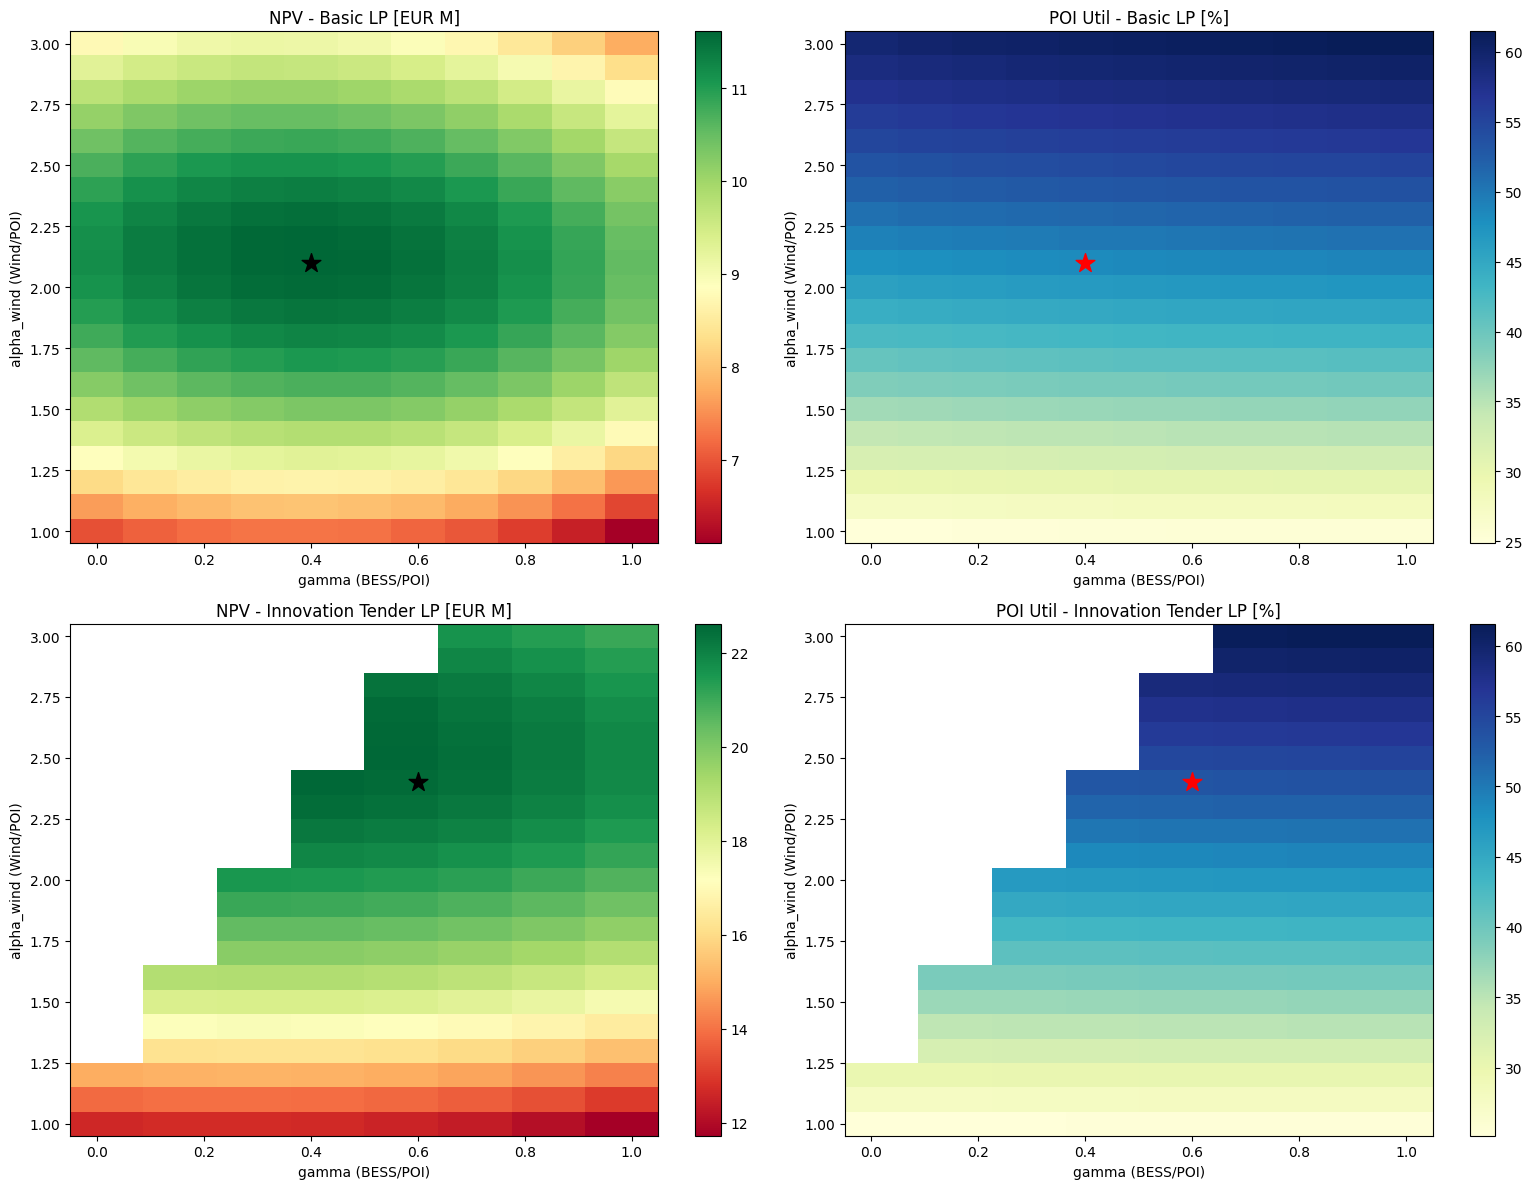

In [5]:
# Heatmaps for both scenarios
df_grid_basic = results_to_dataframe(results_lp_basic)
df_grid_innovation = results_to_dataframe(results_lp_innovation)

# Save results to CSV for high-level comparison
df_grid_basic.to_csv('../data_processed/wind_bess_results.csv', index=False)
df_grid_innovation.to_csv('../data_processed/wind_bess_results_innovation.csv', index=False)
print('Saved results to data_processed/wind_bess_results.csv and wind_bess_results_innovation.csv')

# Create comparison figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Basic LP - NPV
pivot_npv_basic = df_grid_basic.pivot(index='alpha_tot', columns='gamma', values='npv_eur')
im1 = axes[0, 0].imshow(pivot_npv_basic.values/1e6, cmap='RdYlGn', aspect='auto', origin='lower',
    extent=[min(gamma_values)-0.05, max(gamma_values)+0.05, min(alpha_wind_values)-0.05, max(alpha_wind_values)+0.05])
axes[0, 0].scatter([best_lp_basic.gamma], [best_lp_basic.alpha_tot], c='k', s=200, marker='*')
axes[0, 0].set_xlabel('gamma (BESS/POI)'); axes[0, 0].set_ylabel('alpha_wind (Wind/POI)')
axes[0, 0].set_title('NPV - Basic LP [EUR M]')
plt.colorbar(im1, ax=axes[0, 0])

# Basic LP - POI Util
pivot_poi_basic = df_grid_basic.pivot(index='alpha_tot', columns='gamma', values='poi_utilisation')
im2 = axes[0, 1].imshow(pivot_poi_basic.values*100, cmap='YlGnBu', aspect='auto', origin='lower',
    extent=[min(gamma_values)-0.05, max(gamma_values)+0.05, min(alpha_wind_values)-0.05, max(alpha_wind_values)+0.05])
axes[0, 1].scatter([best_lp_basic.gamma], [best_lp_basic.alpha_tot], c='r', s=200, marker='*')
axes[0, 1].set_xlabel('gamma (BESS/POI)'); axes[0, 1].set_ylabel('alpha_wind (Wind/POI)')
axes[0, 1].set_title('POI Util - Basic LP [%]')
plt.colorbar(im2, ax=axes[0, 1])

# Innovation Tender LP - NPV
pivot_npv_innovation = df_grid_innovation.pivot(index='alpha_tot', columns='gamma', values='npv_eur')
im3 = axes[1, 0].imshow(pivot_npv_innovation.values/1e6, cmap='RdYlGn', aspect='auto', origin='lower',
    extent=[min(gamma_values)-0.05, max(gamma_values)+0.05, min(alpha_wind_values)-0.05, max(alpha_wind_values)+0.05])
axes[1, 0].scatter([best_lp_innovation.gamma], [best_lp_innovation.alpha_tot], c='k', s=200, marker='*')
axes[1, 0].set_xlabel('gamma (BESS/POI)'); axes[1, 0].set_ylabel('alpha_wind (Wind/POI)')
axes[1, 0].set_title('NPV - Innovation Tender LP [EUR M]')
plt.colorbar(im3, ax=axes[1, 0])

# Innovation Tender LP - POI Util
pivot_poi_innovation = df_grid_innovation.pivot(index='alpha_tot', columns='gamma', values='poi_utilisation')
im4 = axes[1, 1].imshow(pivot_poi_innovation.values*100, cmap='YlGnBu', aspect='auto', origin='lower',
    extent=[min(gamma_values)-0.05, max(gamma_values)+0.05, min(alpha_wind_values)-0.05, max(alpha_wind_values)+0.05])
axes[1, 1].scatter([best_lp_innovation.gamma], [best_lp_innovation.alpha_tot], c='r', s=200, marker='*')
axes[1, 1].set_xlabel('gamma (BESS/POI)'); axes[1, 1].set_ylabel('alpha_wind (Wind/POI)')
axes[1, 1].set_title('POI Util - Innovation Tender LP [%]')
plt.colorbar(im4, ax=axes[1, 1])

plt.tight_layout()
plt.savefig('../figures/wind_bess_greenfield_heatmaps.png', dpi=150)
plt.show()